100%|██████████| 1000000/1000000 [2:21:55<00:00, 117.43it/s] 


Samples: 1000000, valid: 62458, failed: 0
Encounter counts: {'sun': 46961, 'jupiter': 15497}
Angular error (median, mean, std) [deg]: 0.004872606328751568 0.004955448766366201 0.0018575475649886286
Positional error (median, mean, std) (AU): 0.07702462126067136 0.0770004112754686 0.013269450584305297


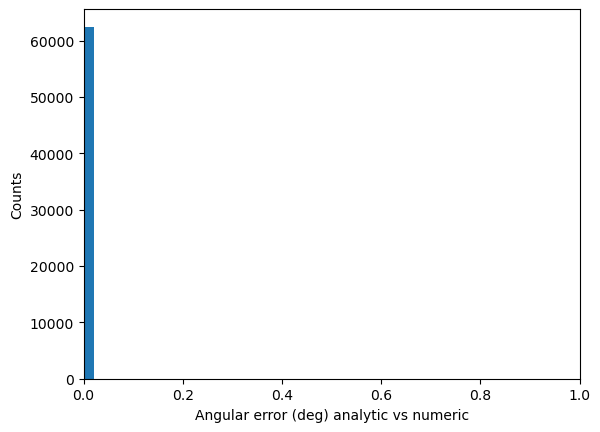

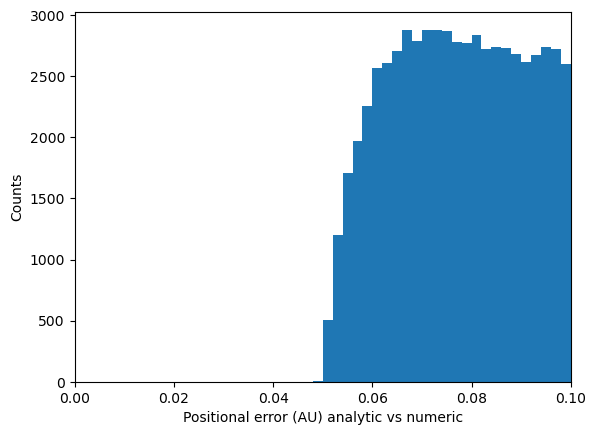

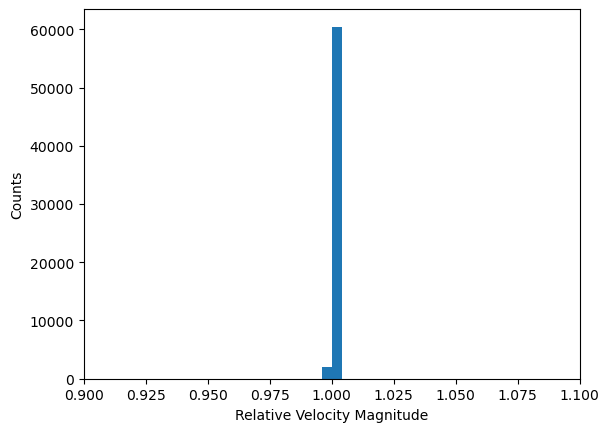

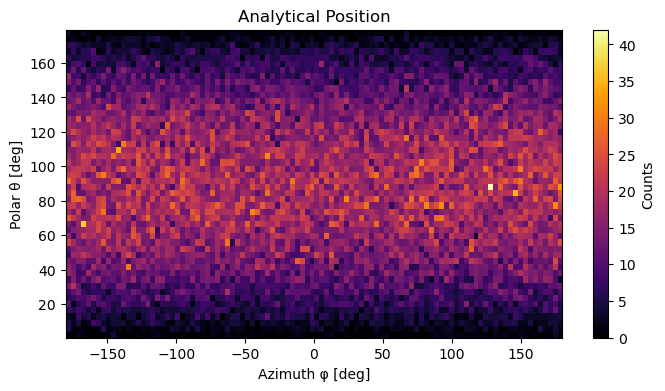

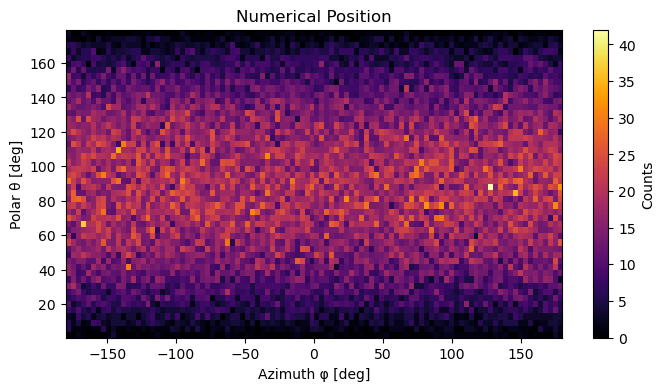

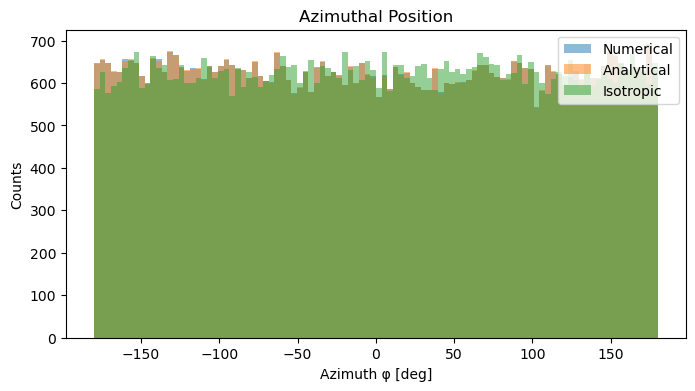

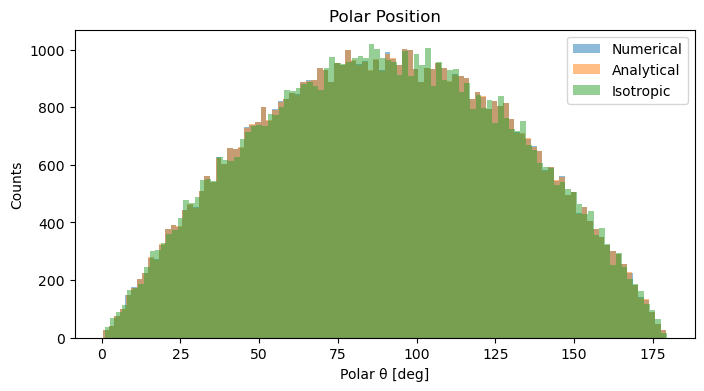

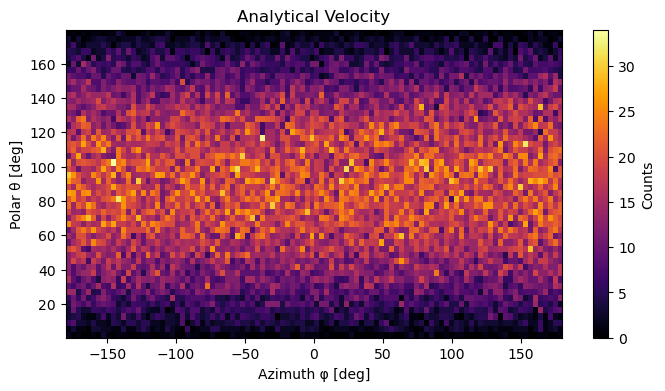

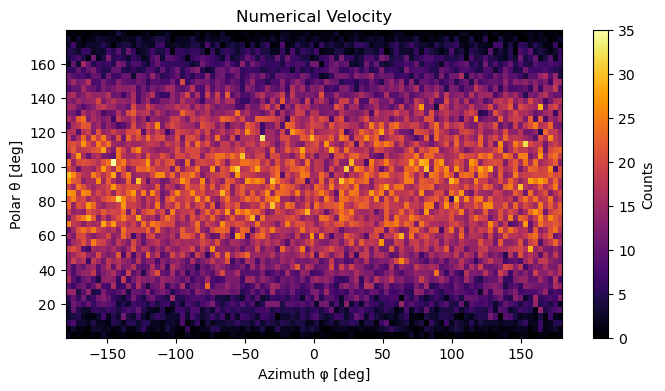

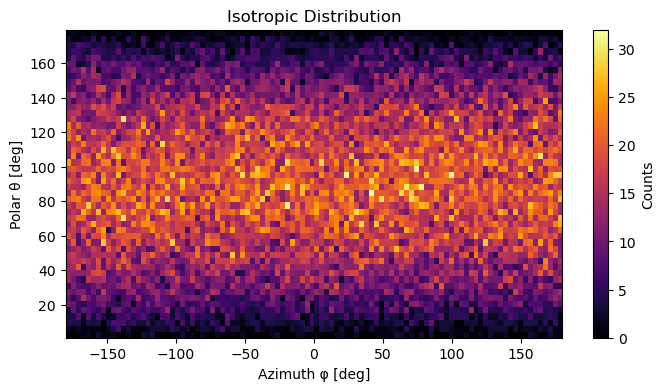

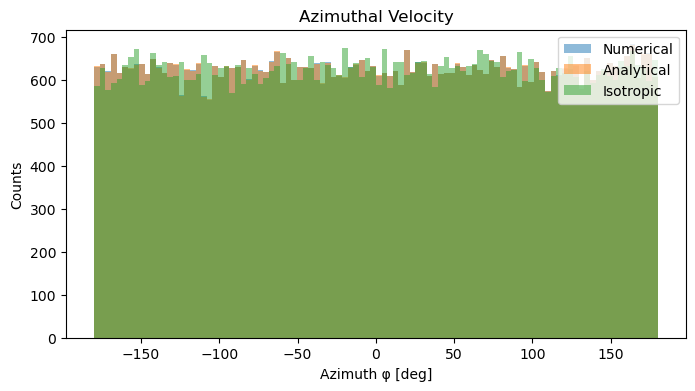

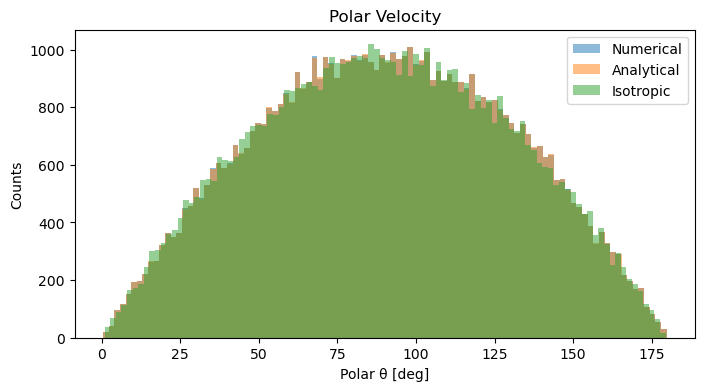

In [1]:
"""
Validation harness: analytic instantaneous velocity at r (Sun vs Jupiter first)
and comparison to full REBOUND integration.
"""
import numpy as np
import rebound
import matplotlib.pyplot as plt
from tqdm import tqdm

G = 0.0377  

def cartesian_to_spherical(v):
    r = np.linalg.norm(v)
    if r == 0:
        return 0.0, 0.0, 0.0
    theta = np.arccos(v[2]/r)        # polar angle (0 = +z)
    phi = np.arctan2(v[1], v[0])     # azimuthal angle
    return r, theta, phi

def build_orthonormal_basis(u):
    """Return two orthonormal vectors e1,e2 perpendicular to u (u assumed unit)."""
    # choose arbitrary vector not parallel to u
    arb = np.array([0.0,0.0,1.0])
    if abs(np.dot(arb, u)) > 0.9:
        arb = np.array([0.0,1.0,0.0])
    e1 = np.cross(u, arb)
    e1 /= np.linalg.norm(e1)
    e2 = np.cross(u, e1)
    e2 /= np.linalg.norm(e2)
    return e1, e2

def instantaneous_velocity_at_r(u_inf, b, phi_b, v_inf, eval_pos, mu):
    """
    Compute instantaneous velocity (3D) at eval_pos on the hyperbola around a center.
    Inputs:
      u_inf: incoming unit vector pointing TOWARD the center (3,)
      b: impact parameter (scalar)
      phi_b: azimuth angle for impact-parameter vector in plane perp to u_inf
      v_inf: speed at infinity
      center_pos: 3-vector center location (AU)
      eval_pos: 3-vector point where we want velocity (AU)
      mu: G*M (units AU^3/yr^2)
    Returns:
      v_vec (3,) instantaneous velocity vector (AU/yr) at eval_pos on inbound branch if reachable,
      reached (bool), inbound_bool (True if inbound, False if outbound relative to center)
    """
    # Build basis
    u = np.array(u_inf, dtype=float)
    u /= np.linalg.norm(u)
    e1, e2 = build_orthonormal_basis(u)  # two perpendicular unit vectors
    # impact-parameter direction (in plane perpendicular to u)
    e_b = np.cos(phi_b) * e1 + np.sin(phi_b) * e2
    # set r_perp vector (position offset at s=0)
    r_perp = b * e_b  # vector perpendicular to u at s=0

    # Parametric unperturbed line: r(s) = r_perp + s * u
    # We want the point on that line which equals eval_pos - center_pos
    rel_eval = np.array(eval_pos, dtype=float) 

    # Solve for s such that r_perp + s*u == rel_eval  (only approximate due to deflection)
    # But we want to know whether eval_pos lies on the unperturbed incoming line. Generally not.
    # Instead, compute radius from center at points along hyperbola; we will first compute hyperbola parameters
    h = b * v_inf
    e = np.sqrt(1.0 + (b**2 * v_inf**4) / (mu**2))
    # check r for the eval_pos relative to center: radial distance
    r_eval = np.linalg.norm(rel_eval)
    # Check if hyperbola reaches r_eval:
    p = h**2 / mu
    cos_nu = (p / (r_eval) - 1.0) / e
    if abs(cos_nu) > 1.0:
        return np.zeros(3), False, None , None # hyperbola does not pass through r_eval

    # Choose inbound branch: sin(nu) negative for inbound
    sin_nu = -np.sqrt(max(0.0, 1.0 - cos_nu**2))
    nu = np.arctan2(sin_nu, cos_nu)

    # Compute periapsis geometry: true anomaly at infinity (asymptote angle):
    cos_nu_inf = -1.0 / e
    sin_nu_inf = np.sqrt(max(0.0, 1.0 - cos_nu_inf**2))
    # Build periapsis direction and theta_p as in analysis
    e_x = -u                # incoming asymptote direction away-from-center
    e_y = e_b               # impact-parameter direction
    p_hat = cos_nu_inf * e_x + sin_nu_inf * e_y
    theta_p = -sin_nu_inf * e_x + cos_nu_inf * e_y

    # Local unit vectors at true anomaly nu
    r_hat = np.cos(nu) * p_hat + np.sin(nu) * theta_p

    # position along hyperbola
    r_vec = (p / (1 + e*cos_nu)) * r_hat
    theta_hat = -np.sin(nu) * p_hat + np.cos(nu) * theta_p

    # radial and transverse speeds
    v_r = (mu / h) * e * sin_nu
    v_theta = (mu / h) * (1.0 + e * cos_nu)
    v_vec = v_r * r_hat + v_theta * theta_hat

    # Determine inbound/outbound: inbound if sin_nu < 0
    inbound = True if sin_nu < 0 else False

    return v_vec, True, inbound, r_vec

def line_closest_param_and_distance(u_inf, b_vec, C):
    """
    For line r(s)=b_vec + s*u_inf, returns s* and min distance to point C.
    s* = argmin_s || r(s)-C ||^2
    """
    u = u_inf
    s_star = -np.dot(b_vec - C, u)
    closest = b_vec + s_star * u
    dmin = np.linalg.norm(closest - C)
    return s_star, dmin, closest

def sample_one(u_inf, v_inf, b, phi_b, r_launch_sphere, r_eval_jupiter, r_J):
    """
    Sample one event:
    - u_inf: incoming direction unit vector pointing TOWARD the Sun (system origin)
    - v_inf: speed at infinity
    - b, phi_b: impact param and azimuth defining the unperturbed asymptote line
    - r_launch_sphere: radius (AU) of launch sphere used to place initial particle; used for numeric integration start
    - r_eval_jupiter: radius around Jupiter (AU) where we want to evaluate velocity (e.g., Jupiter Hill radius or 5 AU)
    - r_J: Jupiter position vector (AU)
    Returns: dict with analytic_v, numeric_v, encountered_first ('sun' or 'jupiter'), reached flags, inbound/outbound booleans 
    """
    # incoming unit vector toward Sun (center at origin)
    u = np.array(u_inf) / np.linalg.norm(u_inf)
    # define impact-parameter vector at s=0
    e1, e2 = build_orthonormal_basis(u)
    e_b = np.cos(phi_b) * e1 + np.sin(phi_b) * e2
    r_perp = b * e_b  # vector in plane perpendicular to u

    # Line param r(s)=r_perp + s*u
    # Find s_star for Sun (center at origin) and Jupiter
    s_sun, d_sun, closest_sun = line_closest_param_and_distance(u, r_perp, np.zeros(3))
    s_j, d_j, closest_j = line_closest_param_and_distance(u, r_perp, r_J)

    # We interpret s increasing as forward along motion toward centers
    # Choose first encountered center as one with smallest positive s_star
    # (only consider s_star > 0, if negative it was behind initial reference)
    s_sun_pos = s_sun if s_sun > 0 else np.inf
    s_j_pos = s_j if s_j > 0 else np.inf
    if s_j_pos < s_sun_pos:
        first = 'jupiter'
    else:
        first = 'sun'

    # Decide eval point: the point on the line where distance to Jupiter equals r_eval_jupiter
    # Solve |r_perp + s*u - r_J|^2 = r_eval_jupiter^2  (quadratic in s)
    C = r_J
    # coefficients for (r_perp + s*u - C)^2 = R^2
    A = 1.0  # u.u
    B = 2.0 * np.dot(u, r_perp - C)
    Cc = np.dot(r_perp - C, r_perp - C) - r_eval_jupiter**2
    disc = B**2 - 4*A*Cc
    if disc < 0:
        # no real crossing of that sphere along unperturbed line
        # fallback: evaluate at closest approach to Jupiter
        # s_closest = -u.(r_perp - r_J)
        #s_eval = -np.dot(u, r_perp - r_J)
        #eval_point = r_perp + s_eval * u
        return None
    else:
        s1 = (-B - np.sqrt(disc)) / (2*A)
        s2 = (-B + np.sqrt(disc)) / (2*A)
        # pick the smaller positive s (first crossing)
        candidates = [s for s in (s1, s2) if s > 0]
        if len(candidates) == 0:
            # both negative -> crossing behind; choose nearer anyway
            s_eval = min(s1, s2, key=abs)
        else:
            s_eval = min(candidates)
        eval_point = r_perp + s_eval * u

    # Based on first encountered center, compute analytic instantaneous velocity at eval_point
    mu_sun = G * 1047.57
    mu_jup = G * (1.0)  # Jupiter mass in Msun units approx
    analytic_v = None
    reached_flag = False
    inbound_outbound = None

    if first == 'sun':
        # Particle reaches Sun first: use Sun hyperbola to compute velocity at eval_point (point near Jupiter)
        # Evaluate relative to Sun center:
        vvec, reached_flag, inbound_outbound, pos_vec_a = instantaneous_velocity_at_r(
            u_inf=u, b=b, phi_b=phi_b, v_inf=v_inf,
            eval_pos=eval_point, mu=mu_sun
        )
        analytic_v = vvec
    else:
        # Particle reaches Jupiter first: use Jupiter hyperbola about Jupiter center, compute inbound velocity at radius r_eval_jupiter
        # For Jupiter-centered hyperbola, incoming asymptote direction relative to Jupiter is still u (approx)
        vvec, reached_flag, inbound_outbound, pos_vec_a = instantaneous_velocity_at_r(
            u_inf=u, b=b, phi_b=phi_b, v_inf=v_inf,
            eval_pos=eval_point, mu=mu_sun
        )
        analytic_v = vvec

    if reached_flag==False:
        return None

    # Numeric integration with REBOUND (Sun + Jupiter)
    # Launch particle at large negative s0 along unperturbed line: position = r_perp + s0*u
    s0 = -10000.0  # AU, sufficiently far
    r0 = r_perp + s0 * u
    v0 = v_inf * u
    sim = rebound.Simulation()
    sim.units = ('yr', 'AU', 'mjupiter')
    sim.add(m=1047.57, hash='Sun')
    sim.add(
        m = 1.0,                      # Jupiter mass in MJ
        a = 5.2044,                   # au
        e = 0.0489,
        inc = np.deg2rad(1.303),
        Omega = np.deg2rad(100.464),
        omega = np.deg2rad(273.867),
        M = np.deg2rad(20.020),
        r = 4.7789e-4,
        hash = "Jupiter"
    )
    sim.add(
        m = 0.299409946,        # Saturn mass in Jupiter masses
        a = 9.5826,          # au
        e = 0.0565,
        inc = np.deg2rad(2.485),
        Omega = np.deg2rad(113.665),
        omega = np.deg2rad(339.392),
        M = np.deg2rad(317.020),
        r = 3.8926e-4,
        hash="Saturn"
    )
    sim.add(x=r0[0], y=r0[1], z=r0[2], vx=v0[0], vy=v0[1], vz=v0[2], hash='ISO')
    sim.N_active=3
    t_est = -s0/v_inf - 100
    sim.integrate(t_est)
    p = sim.particles['ISO']
    r = np.array([p.x, p.y, p.z]) 
    dt=0.01
    max_steps=int(1e8)
    for _ in range(max_steps):
        sim.integrate(sim.t+dt)
        p = sim.particles['ISO']
        r = np.array([p.x, p.y, p.z])
        if np.linalg.norm(r-pos_vec_a)<0.1:
            break
        
    p = sim.particles['ISO']
    numeric_v = np.array([p.vx, p.vy, p.vz])
    numeric_r = np.array([p.x, p.y, p.z])

    # Normalize analytic vector to unit direction for fair angle comparison (we can also compare magnitudes)
    if reached_flag:
        analytic_dir = analytic_v / np.linalg.norm(analytic_v)
    else:
        analytic_dir = np.zeros(3)

    out = dict(
        analytic_v = analytic_v,
        analytic_dir = analytic_dir,
        numeric_v = numeric_v,
        numeric_r = numeric_r,
        encountered_first = first,
        reached = reached_flag,
        inbound = inbound_outbound,
        eval_point = eval_point,
        pos_vec = pos_vec_a
    )
    return out

# ------------------------------
# Run many samples and compare
# ------------------------------
def run_validation(N, r_launch_sphere=10000.0, r_eval_jupiter=250, r_J=np.array([4.54,-2.45,-0.1]), v_inf_mean=5):
    errs_angle = []
    errs_pos = []
    mags_rel = []
    a_theta, a_phi = [], []
    n_theta, n_phi = [], []
    a_vtheta, a_vphi = [], []
    n_vtheta, n_vphi = [], []
    encounters = {'sun':0, 'jupiter':0}
    failed = 0

    for i in tqdm(range(N)):
        # sample isotropic incoming direction pointing TOWARD Sun
        while True:
            cos_ti = 2*np.random.rand() - 1
            phi = 2*np.pi*np.random.rand()
            u = np.array([np.sqrt(1-cos_ti**2)*np.cos(phi), np.sqrt(1-cos_ti**2)*np.sin(phi), cos_ti])
            # ensure u points toward Sun? By construction with Sun at origin, any direction is fine; we keep it
            break
        # sample v_inf from distribution or use fixed
        v_inf = v_inf_mean  # keep fixed or randomize
        # sample impact parameter b up to some max area around origin
        bmax = 1000.0
        b = bmax * np.sqrt(np.random.rand())
        phi_b = 2*np.pi*np.random.rand()

        out = sample_one(u, v_inf, b, phi_b, r_launch_sphere, r_eval_jupiter, r_J)
        if out is None:
            continue
        if not out['reached']:
            failed += 1
            continue
        encounters[out['encountered_first']] += 1

        # compute angular difference between analytic_dir and numeric_v
        a = out['analytic_dir']
        va = out['analytic_v']
        n = out['numeric_v']
        n_dir = n/np.linalg.norm(n)
        r = out['numeric_r']
        pos_vec = out['pos_vec']
        pos_err = np.linalg.norm(r - pos_vec)
        if np.linalg.norm(a) < 1e-12:
            failed += 1
            continue
        cosang = np.clip(np.dot(a, n_dir), -1.0, 1.0)
        ang = np.arccos(cosang)
        errs_angle.append(ang)
        errs_pos.append(pos_err)
        mags_rel.append(np.linalg.norm(out['analytic_v']) /  np.linalg.norm(out['numeric_v']))
        _a, thetaa, phia = cartesian_to_spherical(pos_vec-np.array([5.2,0,0]))
        a_theta.append(thetaa)
        a_phi.append(phia)
        _n, thetan, phin = cartesian_to_spherical(r-np.array([5.2,0,0]))
        n_theta.append(thetan)
        n_phi.append(phin)
        _av, thetaav, phiav = cartesian_to_spherical(va)
        a_vtheta.append(thetaav)
        a_vphi.append(phiav)
        _nv, thetanv, phinv = cartesian_to_spherical(n)
        n_vtheta.append(thetanv)
        n_vphi.append(phinv)
        

    print(f"Samples: {N}, valid: {len(errs_angle)}, failed: {failed}")
    print("Encounter counts:", encounters)
    print("Angular error (median, mean, std) [deg]:",
          np.median(errs_angle)*180/np.pi, np.mean(errs_angle)*180/np.pi, np.std(errs_angle)*180/np.pi)
    print("Positional error (median, mean, std) (AU):",
          np.median(errs_pos), np.mean(errs_pos), np.std(errs_pos))
    thetaiso = np.arccos(1 - 2 * np.random.uniform(0, 1, len(n_vphi)))
    phiiso = np.random.uniform(-np.pi, np.pi, len(n_vphi))
    thetaiso = np.degrees(thetaiso)
    phiiso = np.degrees(phiiso)

    # Plot histogram of angle errors
    plt.figure()
    plt.hist(np.array(errs_angle)*180/np.pi, bins=50, range=(0,1))
    plt.xlabel("Angular error (deg) analytic vs numeric")
    plt.xlim(0,1)
    plt.ylabel("Counts")
    plt.show()

    plt.figure()
    plt.hist(errs_pos, bins=50, range=(0,0.1))
    plt.xlabel("Positional error (AU) analytic vs numeric")
    plt.ylabel("Counts")
    plt.xlim(0,0.1)
    plt.show()

    plt.figure()
    plt.hist(mags_rel, bins=50, range=(0.9,1.1))
    plt.xlabel("Relative Velocity Magnitude")
    plt.ylabel("Counts") 
    plt.xlim(0.9,1.1)
    plt.show()

    a_phi_deg = np.degrees(a_phi)
    a_theta_deg = np.degrees(a_theta)
    H, xedges, yedges = np.histogram2d(a_phi_deg, a_theta_deg, bins=[100, 50])  # 5° bins
    plt.figure(figsize=(8,4))
    plt.imshow(H.T, origin='lower',
               extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
               aspect='auto', cmap='inferno')
    plt.xlabel('Azimuth φ [deg]')
    plt.ylabel('Polar θ [deg]')
    plt.title('Analytical Position')
    plt.colorbar(label='Counts')
    plt.show()

    n_phi_deg = np.degrees(n_phi)
    n_theta_deg = np.degrees(n_theta)
    H, xedges, yedges = np.histogram2d(n_phi_deg, n_theta_deg, bins=[100, 50]) 
    plt.figure(figsize=(8,4))
    plt.imshow(H.T, origin='lower',
               extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
               aspect='auto', cmap='inferno')
    plt.xlabel('Azimuth φ [deg]')
    plt.ylabel('Polar θ [deg]')
    plt.title('Numerical Position')
    plt.colorbar(label='Counts')
    plt.show()

    plt.figure(figsize=(8,4))
    plt.hist(n_phi_deg, bins=100, label="Numerical", alpha = 0.5)
    plt.hist(a_phi_deg, bins=100, label="Analytical", alpha = 0.5)
    plt.hist(phiiso, bins=100, label="Isotropic", alpha = 0.5)
    plt.xlabel('Azimuth φ [deg]')
    plt.ylabel('Counts')
    plt.legend()
    plt.title('Azimuthal Position')

    plt.figure(figsize=(8,4))
    plt.hist(n_theta_deg, bins=100, label="Numerical", alpha = 0.5)
    plt.hist(a_theta_deg, bins=100, label="Analytical", alpha = 0.5)
    plt.hist(thetaiso, bins=100, label="Isotropic", alpha = 0.5)
    plt.xlabel('Polar θ [deg]')
    plt.ylabel('Counts')
    plt.legend()
    plt.title('Polar Position')

    av_phi_deg = np.degrees(a_vphi)
    av_theta_deg = np.degrees(a_vtheta)
    H, xedges, yedges = np.histogram2d(av_phi_deg, av_theta_deg, bins=[100, 50])  
    plt.figure(figsize=(8,4))
    plt.imshow(H.T, origin='lower',
               extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
               aspect='auto', cmap='inferno')
    plt.xlabel('Azimuth φ [deg]')
    plt.ylabel('Polar θ [deg]')
    plt.title('Analytical Velocity')
    plt.colorbar(label='Counts')
    plt.show()

    nv_phi_deg = np.degrees(n_vphi)
    nv_theta_deg = np.degrees(n_vtheta)
    H, xedges, yedges = np.histogram2d(nv_phi_deg, nv_theta_deg, bins=[100, 50]) 
    plt.figure(figsize=(8,4))
    plt.imshow(H.T, origin='lower',
               extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
               aspect='auto', cmap='inferno')
    plt.xlabel('Azimuth φ [deg]')
    plt.ylabel('Polar θ [deg]')
    plt.title('Numerical Velocity')
    plt.colorbar(label='Counts')
    plt.show()

    H, xedges, yedges = np.histogram2d(phiiso, thetaiso, bins=[100, 50]) 
    plt.figure(figsize=(8,4))
    plt.imshow(H.T, origin='lower',
               extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
               aspect='auto', cmap='inferno')
    plt.xlabel('Azimuth φ [deg]')
    plt.ylabel('Polar θ [deg]')
    plt.title('Isotropic Distribution')
    plt.colorbar(label='Counts')
    plt.show() 

    plt.figure(figsize=(8,4))
    plt.hist(nv_phi_deg, bins=100, label="Numerical", alpha = 0.5)
    plt.hist(av_phi_deg, bins=100, label="Analytical", alpha = 0.5)
    plt.hist(phiiso, bins=100, label="Isotropic", alpha = 0.5)
    plt.xlabel('Azimuth φ [deg]')
    plt.ylabel('Counts')
    plt.legend()
    plt.title('Azimuthal Velocity')

    plt.figure(figsize=(8,4))
    plt.hist(nv_theta_deg, bins=100, label="Numerical", alpha = 0.5)
    plt.hist(av_theta_deg, bins=100, label="Analytical", alpha = 0.5)
    plt.hist(thetaiso, bins=100, label="Isotropic", alpha = 0.5)
    plt.xlabel('Polar θ [deg]')
    plt.ylabel('Counts')
    plt.legend()
    plt.title('Polar Velocity')
    
    return errs_angle, mags_rel

N = int(1e6)
errs, mags = run_validation(N)